# Credit Card Default Prediction — Exploratory Data Analysis

Predict whether a credit-card client will default on next month's payment using the UCI 'Default of Credit Card Clients' dataset (30,000 Taiwanese clients, 23 demographic and credit-history features).

**Target:** `default` (0 = No Default, 1 = Default)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/credit_card_default.csv')
df = df.rename(columns={'default.payment.next.month': 'default'})
df = df.drop(columns=['ID']) if 'ID' in df.columns else df
print('Shape:', df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (30000, 24)

Dtypes:
float64    13
int64      11
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 35
Memory (MB): 5.49


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

No explicit NaN values


## 4. Target Variable Distribution

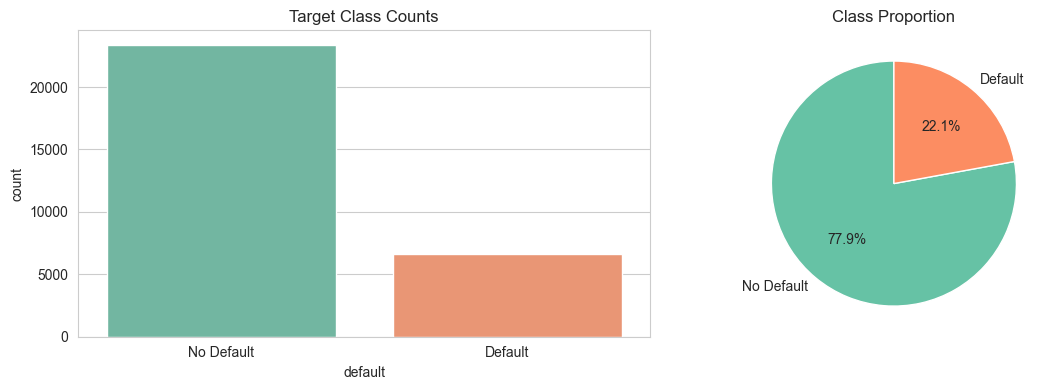


Class balance (%):
default
0    77.88
1    22.12
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['default'].value_counts().sort_index()
sns.countplot(x='default', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['No Default', 'Default'])
axes[1].pie(target_counts, labels=['No Default', 'Default'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'default' in numeric_cols:
    numeric_cols.remove('default')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (23):
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


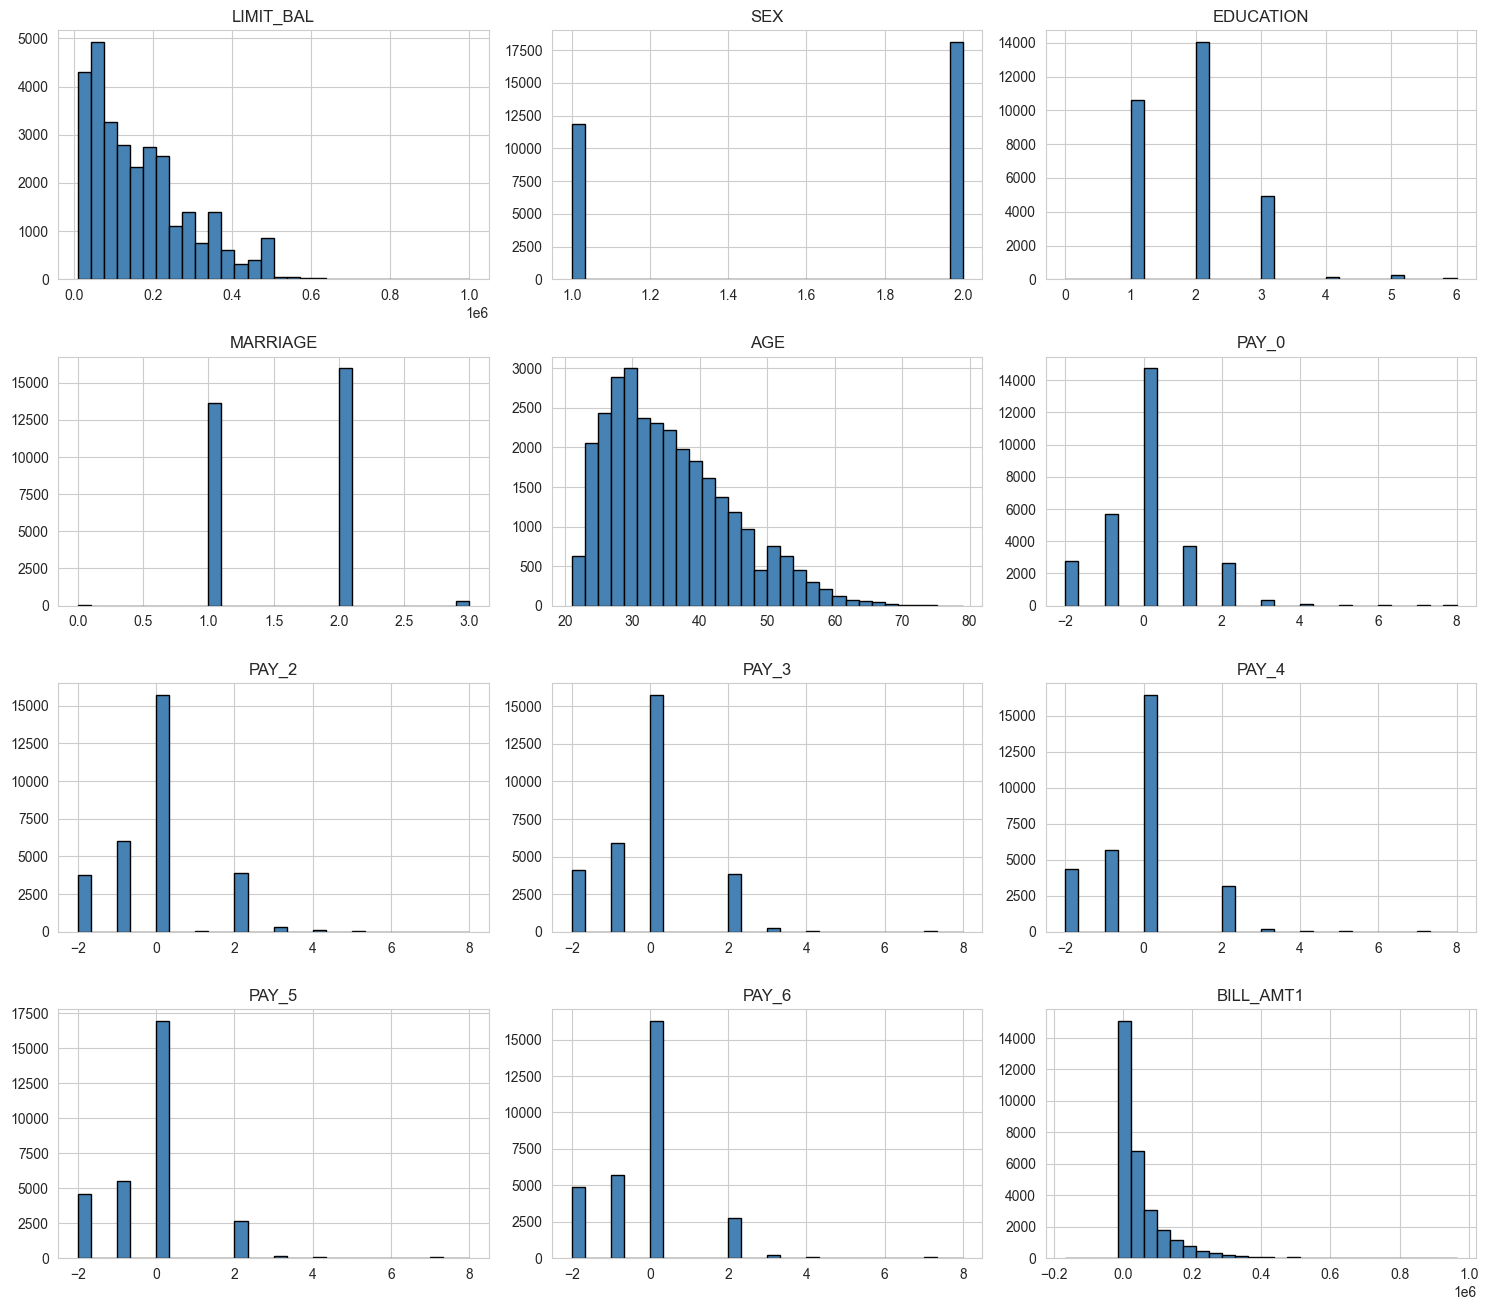

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

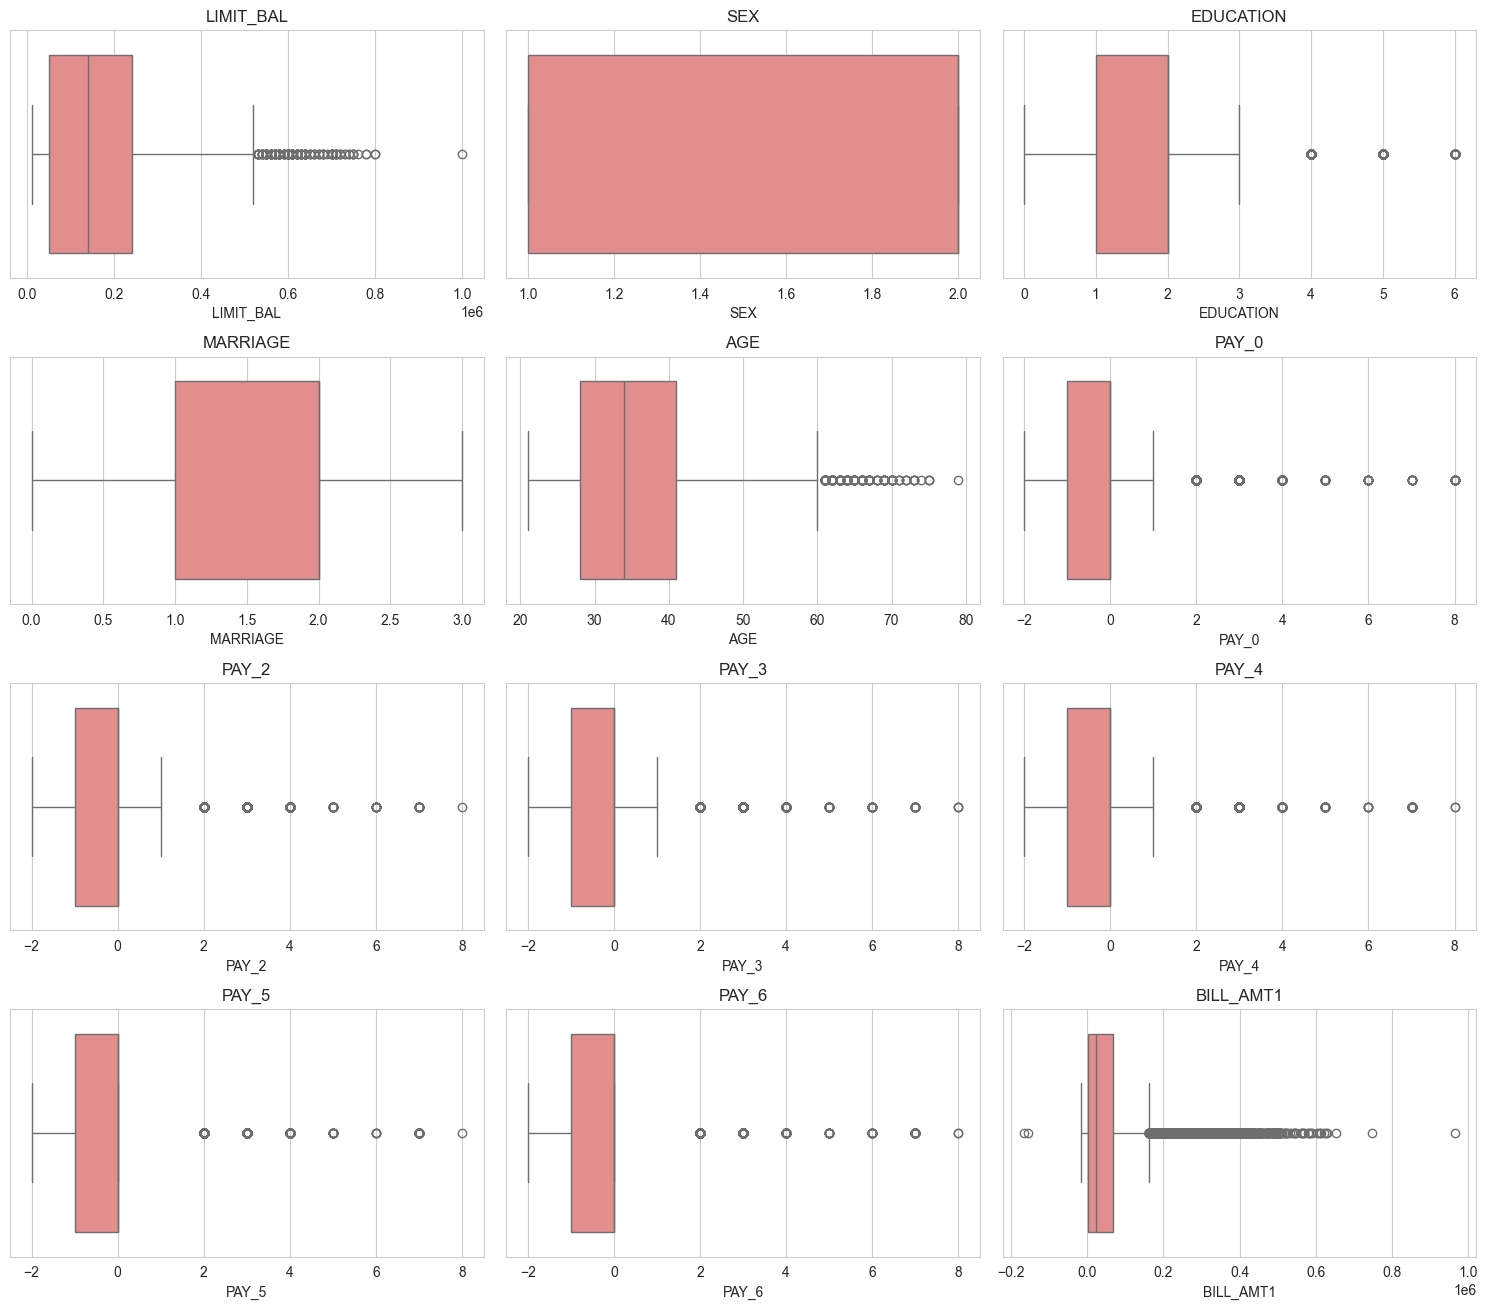

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['default']].corr()['default'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'default'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
PAY_0    0.325
PAY_2    0.264
PAY_3    0.235
PAY_4    0.217
PAY_5    0.204
PAY_6    0.187
Name: default, dtype: float64


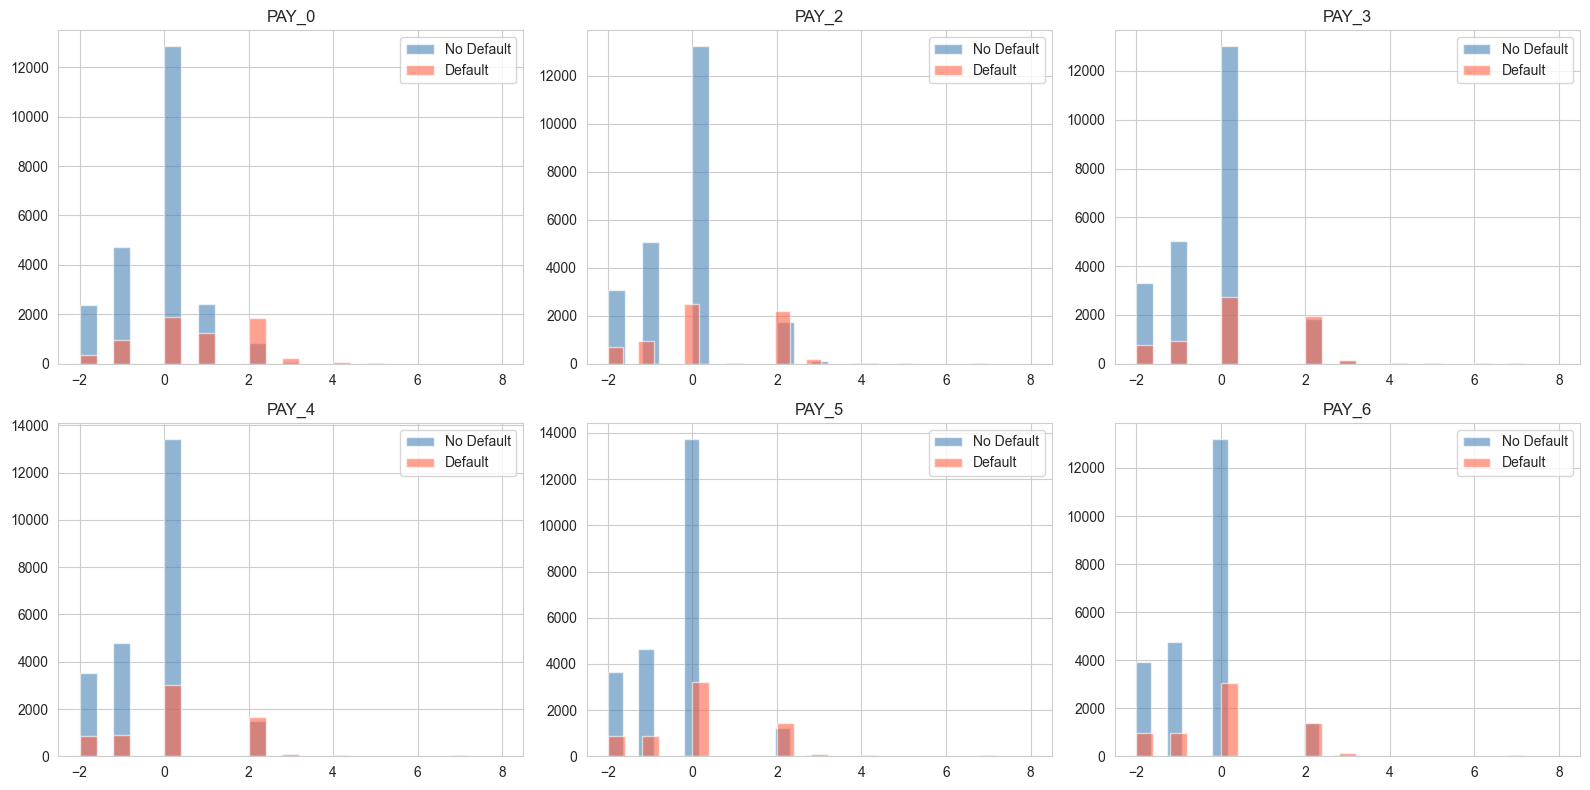

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['No Default', 'Default']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['default']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('default')[numeric_cols].mean().T
means.columns = ['No Default', 'Default']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,No Default,Default,Difference
LIMIT_BAL,178099.726,130109.656,-47990.070
BILL_AMT1,51994.227,48509.162,-3485.065
PAY_AMT2,6640.465,3388.650,-3251.815
PAY_AMT1,6307.337,3397.044,-2910.293
BILL_AMT2,49717.436,47283.618,-2433.818
PAY_AMT3,5753.497,3367.352,-2386.145
BILL_AMT3,47533.366,45181.599,-2351.767
PAY_AMT6,5719.372,3441.482,-2277.890
PAY_AMT4,5300.529,3155.627,-2144.903
PAY_AMT5,5248.220,3219.140,-2029.081


## 7. Correlation Analysis

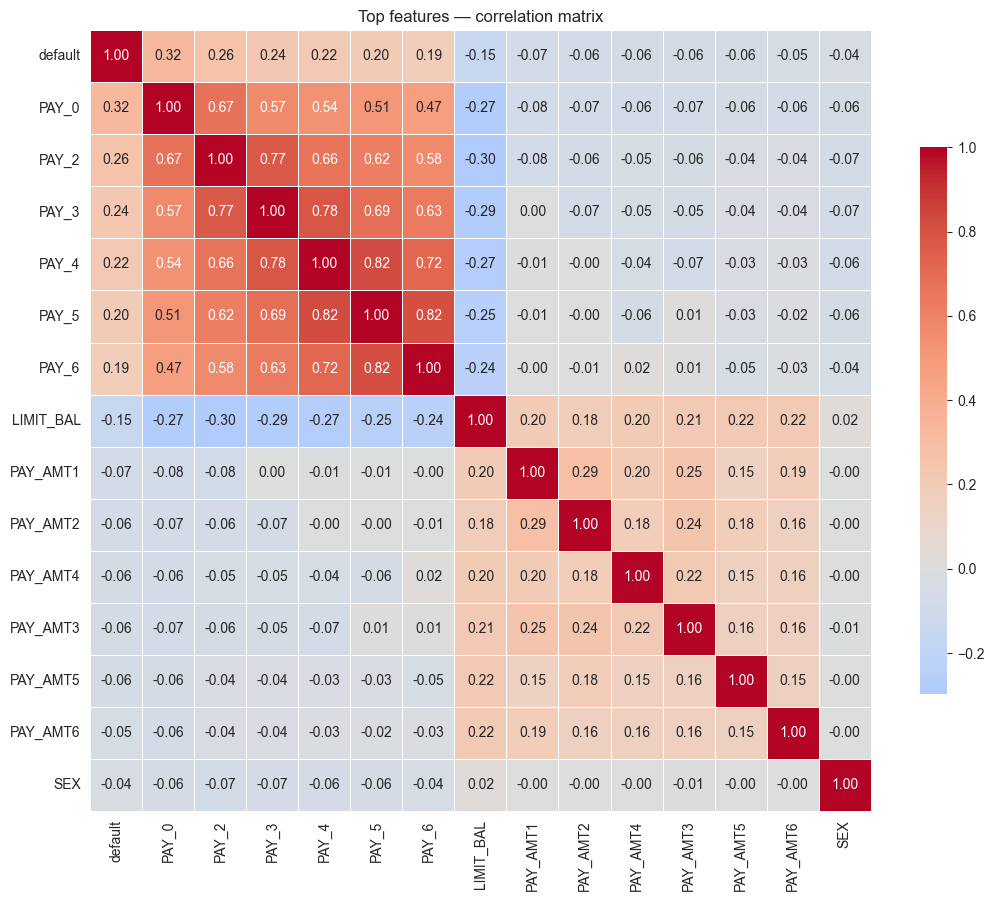

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'default' not in top_numeric:
    top_numeric.append('default')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

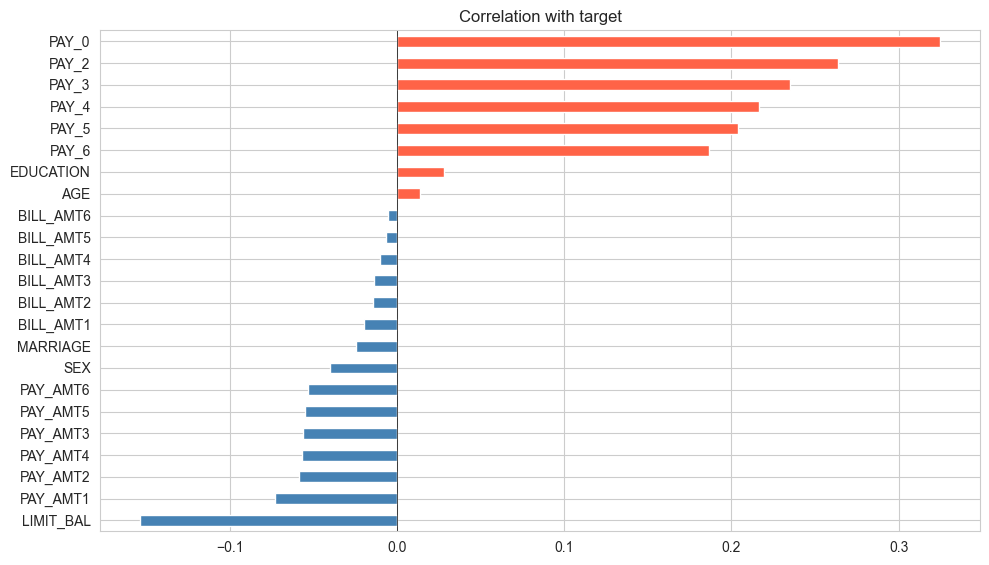

In [15]:
target_corr = df[numeric_cols + ['default']].corr()['default'].drop('default').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Payment History & Demographics

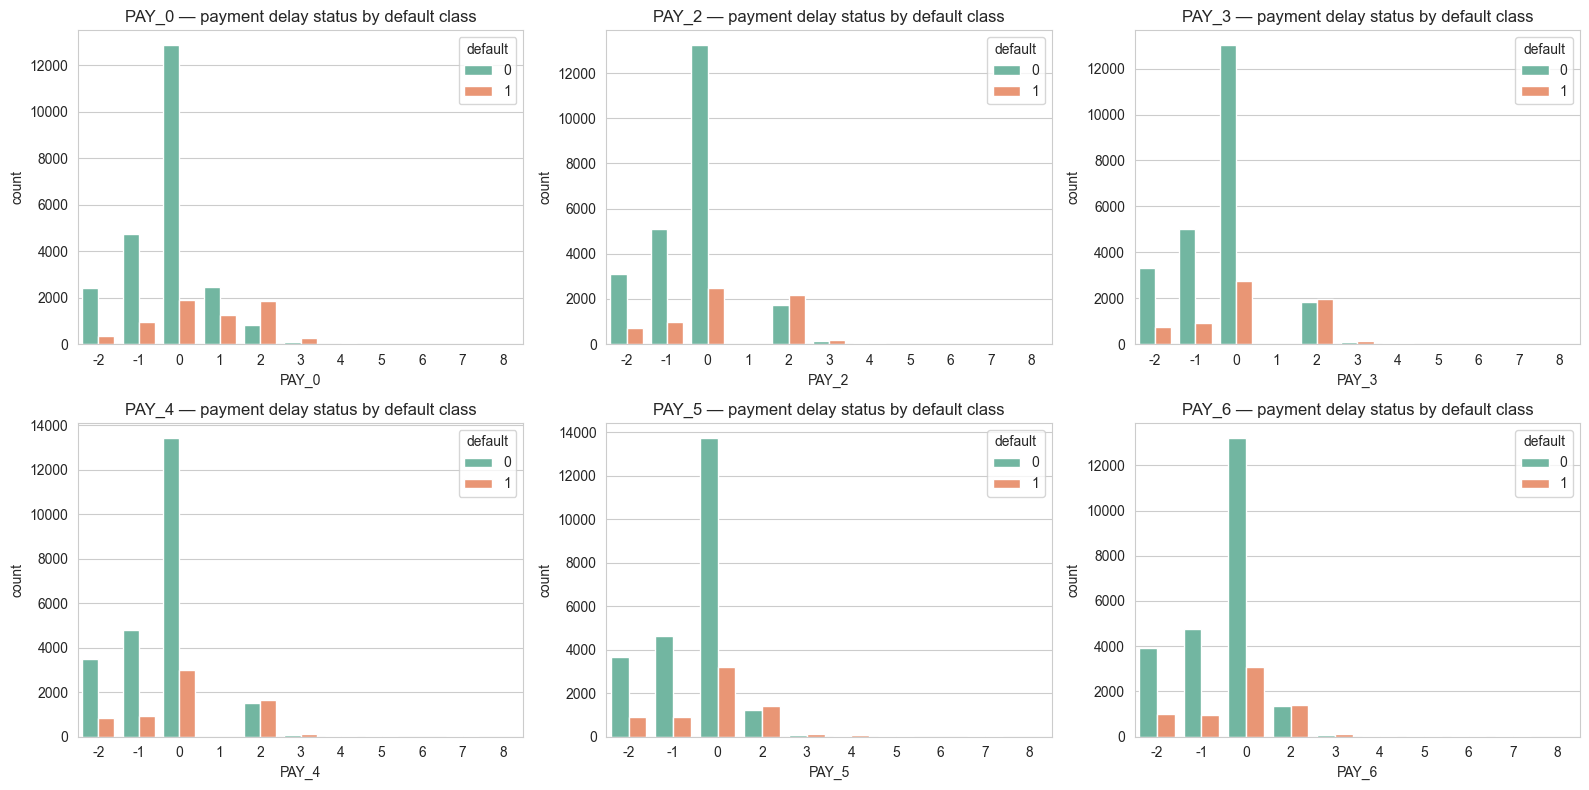

In [16]:
pay_status_cols = ['PAY_0'] + [f'PAY_{i}' for i in range(2, 7)]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(pay_status_cols):
    sns.countplot(x=col, hue='default', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} — payment delay status by default class')
plt.tight_layout(); plt.show()

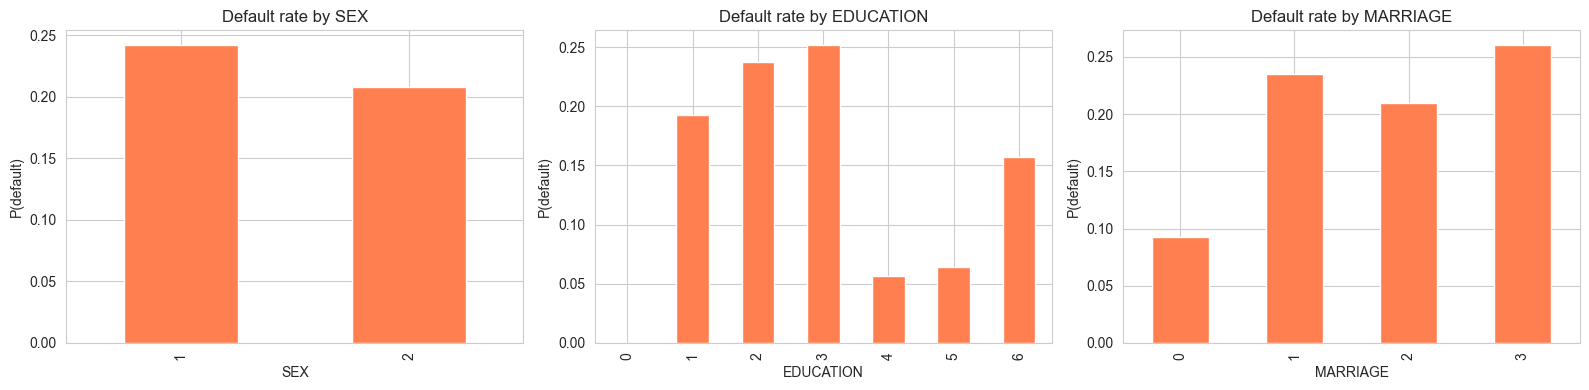

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    rate = df.groupby(col)['default'].mean().sort_index()
    rate.plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Default rate by {col}'); ax.set_ylabel('P(default)')
plt.tight_layout(); plt.show()

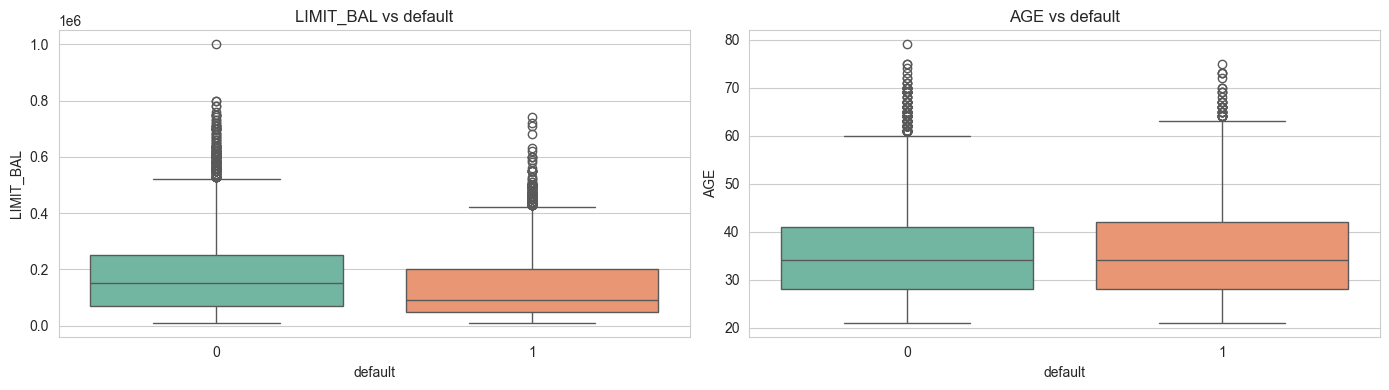

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x='default', y='LIMIT_BAL', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('LIMIT_BAL vs default')
sns.boxplot(x='default', y='AGE', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('AGE vs default')
plt.tight_layout(); plt.show()

## 9. Pair Plot of Top Features

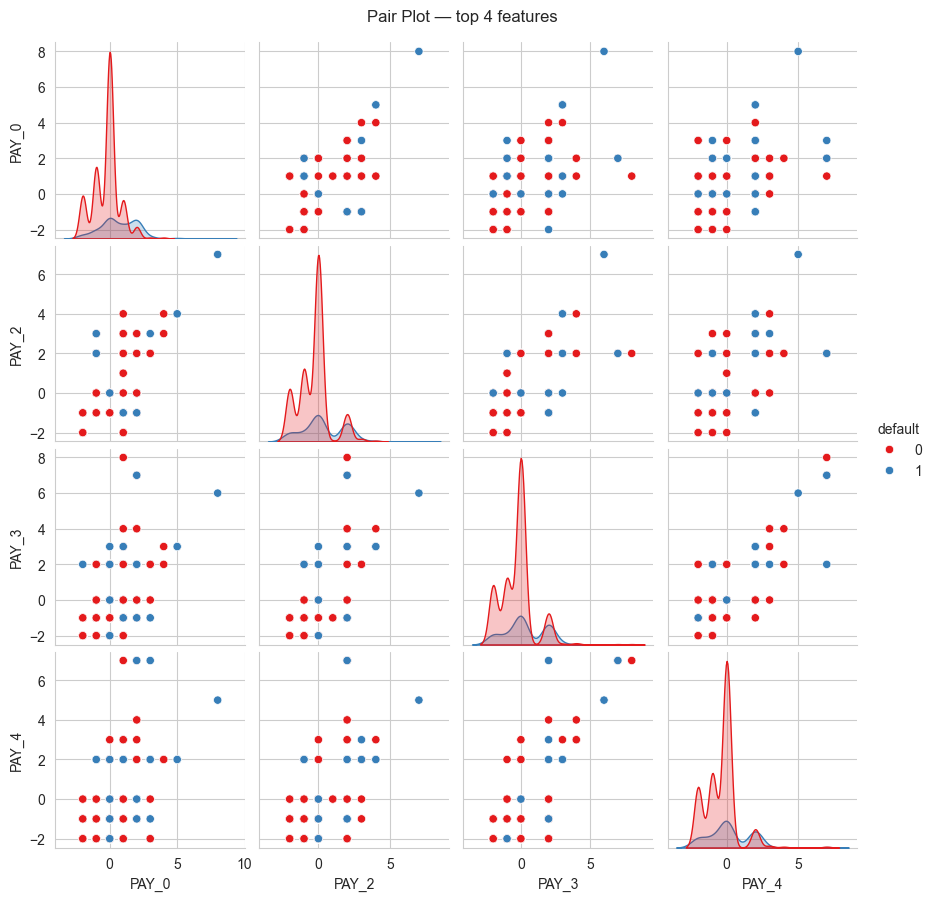

In [19]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['default']].dropna(),
             hue='default', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [20]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['default'] == 0).sum()),
        int((df['default'] == 1).sum()),
        f"{(df['default'] == 0).sum() / max(1, (df['default'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,30000
1,Total features,23
2,Class 0 count,23364
3,Class 1 count,6636
4,Class imbalance ratio,3.52:1
5,Top correlated feature,PAY_0
6,Top correlation value,0.325
